# ESoC 2026 — CLAAS: Labeling Problems & Fixes

This notebook documents two concrete problems found in the initial episode/spike detection logic,
demonstrates them visually, then fixes them step by step.

**Problem 1** — Missed episode when recording starts with header already On  
**Problem 2** — Threshold too sensitive, firing on background noise instead of real stone spikes

In [1]:
from asammdf import MDF
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

DATA_DIR = Path("data")
MF4_FILES = sorted(DATA_DIR.glob("*.mf4"))

# Run 2 is the clearest case to demonstrate both problems
RUN2 = MF4_FILES[1]  # Messung_2025-05-14_16-02-23.mf4
print("Focus file:", RUN2.name)

Focus file: Messung_2025-05-14_16-02-23.mf4


---
## Part 1 — Demonstrate the broken behaviour

### 1a. Problem 1: Missed episode at recording start

The original code finds episodes by looking for **Off → On** transitions.
If the recording starts while the header is already On, there is no such transition —
so the whole opening episode is silently dropped.

In [3]:
def get_episodes_broken(status_channel):
    """Original (broken) version — misses episode if recording starts mid-On."""
    s = status_channel.samples.astype(str)
    t = status_channel.timestamps
    changes = np.where(s[:-1] != s[1:])[0]
    episodes = []
    for i in changes:
        if s[i] == 'Off' and s[i+1] == 'On':
            start = t[i+1]
            future_off = [t[j+1] for j in changes if j > i and s[j] == 'On' and s[j+1] == 'Off']
            end = future_off[0] if future_off else t[-1]
            episodes.append((start, end))
    return episodes

mf2 = MDF(RUN2)
status2 = mf2.get("Status")
s_str = status2.samples.astype(str)

print("=== Problem 1 demonstration ===")
print(f"First Status value at t=0: '{s_str[0]}'")
print(f"  → Recording starts with header already: {s_str[0]}")
print()

broken_episodes = get_episodes_broken(status2)
print(f"Episodes found by broken code: {len(broken_episodes)}")
for i, (s, e) in enumerate(broken_episodes):
    print(f"  Episode {i+1}: {s:.2f}s → {e:.2f}s")

print()
print("But looking at the raw Status transitions:")
changes = np.where(s_str[:-1] != s_str[1:])[0]
for i in changes:
    print(f"  t={status2.timestamps[i]:.2f}s: {s_str[i]} → {s_str[i+1]}")

=== Problem 1 demonstration ===
First Status value at t=0: 'On'
  → Recording starts with header already: On

Episodes found by broken code: 1
  Episode 1: 93.53s → 120.65s

But looking at the raw Status transitions:
  t=23.84s: On → Off
  t=93.51s: Off → On
  t=120.63s: On → Off


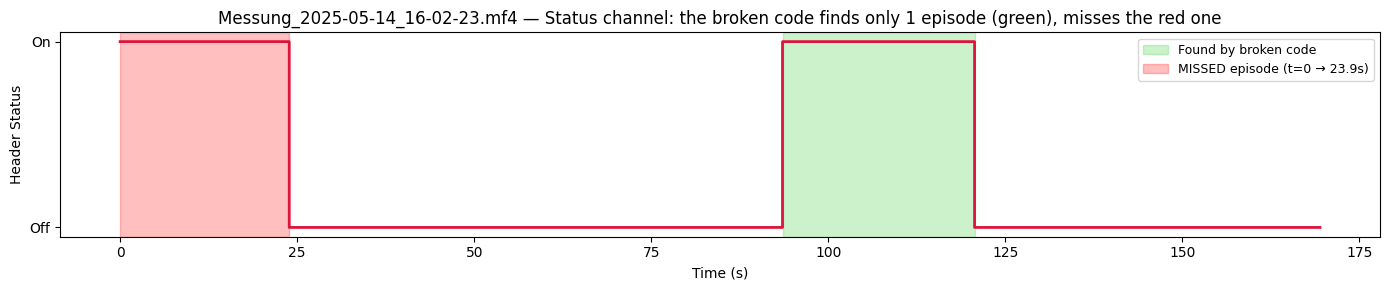

Missed episode spans: t=0 → t=23.88s  (23.9s of harvesting ignored)


In [4]:
# Visualise: show first 40s of Status channel — the missed episode is obvious
fig, ax = plt.subplots(figsize=(14, 3))
status_bin = (s_str == 'On').astype(int)
ax.step(status2.timestamps, status_bin, color='crimson', lw=2, where='post')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Off', 'On'])
ax.set_xlabel("Time (s)")
ax.set_ylabel("Header Status")
ax.set_title(f"{RUN2.name} — Status channel: the broken code finds only 1 episode (green), misses the red one")

# Mark what broken code finds
for s, e in broken_episodes:
    ax.axvspan(s, e, alpha=0.25, color='limegreen', label='Found by broken code')

# Mark the missed episode: starts at t=0 while already On, ends at first Off
first_off = status2.timestamps[changes[0] + 1]
ax.axvspan(0, first_off, alpha=0.25, color='red', label=f'MISSED episode (t=0 → {first_off:.1f}s)')

ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Missed episode spans: t=0 → t={first_off:.2f}s  ({first_off:.1f}s of harvesting ignored)")

### 1b. Problem 2: Threshold firing on background noise

The original threshold = `median + 5×std` of the **first 5% of the whole run**.  
This produces a threshold of ~370.  
The real stone spike reaches 10,668.  
The ratio is 28:1 — the threshold is catching noise, not stones.

In [5]:
volt2 = mf2.get("VoltageSignal")
v = volt2.samples
t = volt2.timestamps

# Original threshold logic
n_baseline = max(50, len(v) // 20)
baseline_global = np.median(v[:n_baseline])
noise_global    = np.std(v[:n_baseline])
threshold_broken = baseline_global + 5.0 * max(noise_global, 1.0)

# Count false spikes
spike_mask = v > threshold_broken
edges = np.diff(spike_mask.astype(int))
all_spike_times = t[np.where(edges == 1)[0] + 1]

# Which are outside the only detected episode?
ep_start, ep_end = broken_episodes[0]
outside = all_spike_times[(all_spike_times < ep_start) | (all_spike_times > ep_end)]
inside  = all_spike_times[(all_spike_times >= ep_start) & (all_spike_times <= ep_end)]

print("=== Problem 2 demonstration ===")
print(f"Global baseline median  : {baseline_global:.1f}")
print(f"Global baseline std     : {noise_global:.1f}")
print(f"Threshold (broken)      : {threshold_broken:.1f}")
print(f"Actual max spike value  : {v.max():.0f}")
print(f"Ratio max/threshold     : {v.max()/threshold_broken:.1f}x")
print()
print(f"Total spike onsets detected : {len(all_spike_times)}")
print(f"  Inside  detected episode  : {len(inside)}")
print(f"  Outside detected episode  : {len(outside)}  ← definite false positives")
print()
print("Outside spike voltage values (should be noise, not stones):")
for st in outside[:8]:
    idx = np.argmin(np.abs(t - st))
    print(f"  t={st:.2f}s  peak voltage={v[idx]:.1f}")

=== Problem 2 demonstration ===
Global baseline median  : 90.0
Global baseline std     : 56.1
Threshold (broken)      : 370.6
Actual max spike value  : 10668
Ratio max/threshold     : 28.8x

Total spike onsets detected : 36
  Inside  detected episode  : 17
  Outside detected episode  : 19  ← definite false positives

Outside spike voltage values (should be noise, not stones):
  t=8.85s  peak voltage=371.0
  t=11.49s  peak voltage=371.0
  t=11.93s  peak voltage=371.0
  t=12.22s  peak voltage=372.0
  t=13.03s  peak voltage=372.0
  t=15.17s  peak voltage=372.0
  t=15.42s  peak voltage=372.0
  t=15.44s  peak voltage=373.0


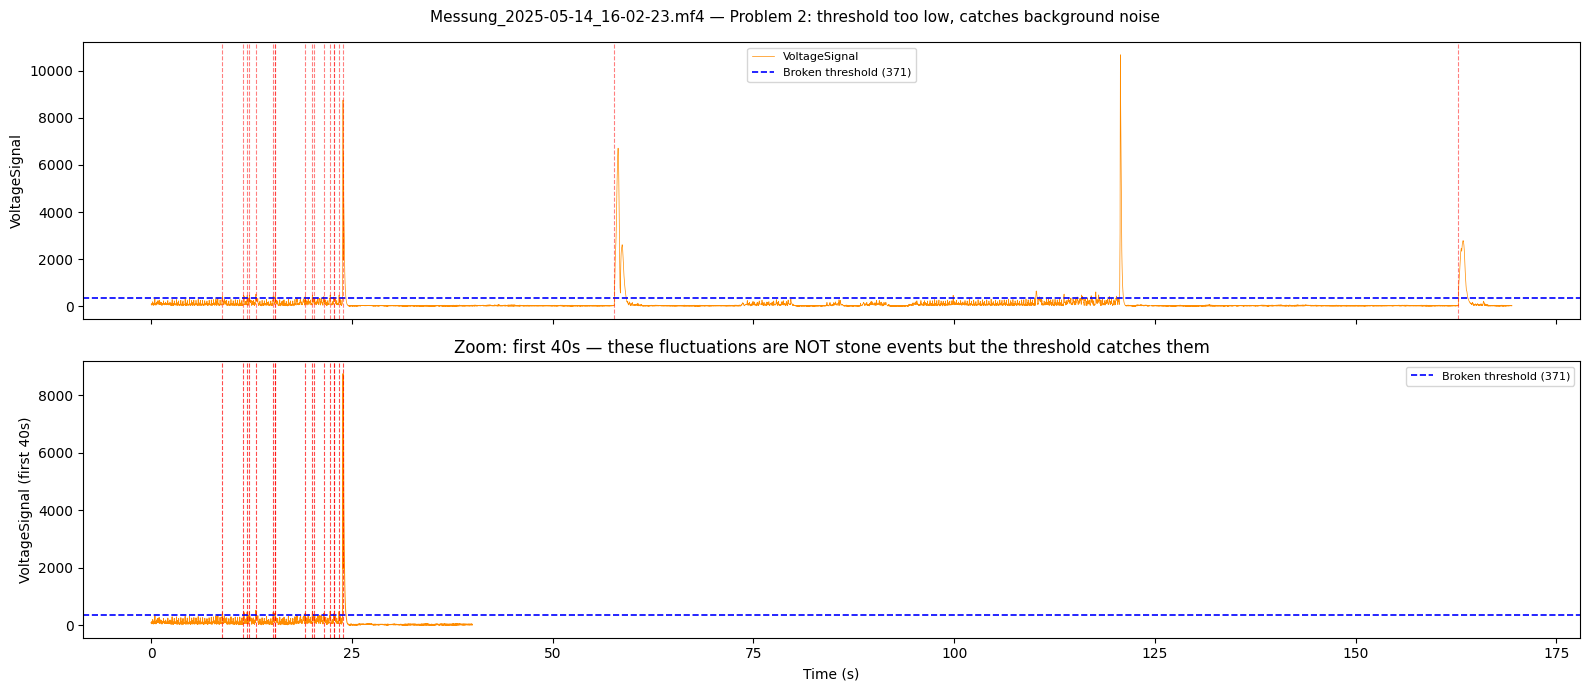

In [6]:
# Visualise the broken threshold against the full signal
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
fig.suptitle(f"{RUN2.name} — Problem 2: threshold too low, catches background noise", fontsize=11)

ax1.plot(t, v, lw=0.5, color='darkorange', label='VoltageSignal')
ax1.axhline(threshold_broken, color='blue', lw=1.2, linestyle='--',
            label=f'Broken threshold ({threshold_broken:.0f})')
ax1.set_ylabel("VoltageSignal")
ax1.legend(fontsize=8)

# Zoom to first 40s to see the noise spikes clearly
mask_40 = t <= 40
ax2.plot(t[mask_40], v[mask_40], lw=0.7, color='darkorange')
ax2.axhline(threshold_broken, color='blue', lw=1.2, linestyle='--',
            label=f'Broken threshold ({threshold_broken:.0f})')
ax2.set_ylabel("VoltageSignal (first 40s)")
ax2.set_xlabel("Time (s)")
ax2.set_title("Zoom: first 40s — these fluctuations are NOT stone events but the threshold catches them")
ax2.legend(fontsize=8)

for st in outside:
    ax1.axvline(st, color='red', lw=0.8, alpha=0.5, linestyle='--')
    if st <= 40:
        ax2.axvline(st, color='red', lw=0.8, alpha=0.7, linestyle='--')

plt.tight_layout()
plt.show()

---
## Part 2 — Fix both problems

### Fix 1: Episode detection that handles recording starting mid-On

Rule: if the very first Status value is `On`, treat `t=0` as the start of an episode.

In [7]:
def get_episodes_fixed(status_channel):
    """
    Fixed episode detection.
    Handles the case where the recording starts with the header already On.
    Returns list of (start_time, end_time) for each On period.
    """
    s = status_channel.samples.astype(str)
    t = status_channel.timestamps
    changes = np.where(s[:-1] != s[1:])[0]
    
    # Build a list of (event_time, new_state) including t=0
    events = [(t[0], s[0])]  # seed with initial state
    for i in changes:
        events.append((t[i+1], s[i+1]))
    
    episodes = []
    ep_start = None
    for ev_time, ev_state in events:
        if ev_state == 'On' and ep_start is None:
            ep_start = ev_time
        elif ev_state == 'Off' and ep_start is not None:
            episodes.append((ep_start, ev_time))
            ep_start = None
    # If run ends while still On
    if ep_start is not None:
        episodes.append((ep_start, t[-1]))
    return episodes

fixed_episodes = get_episodes_fixed(status2)
print("=== Fix 1 result ===")
print(f"Broken code found : {len(broken_episodes)} episode(s)")
print(f"Fixed code finds  : {len(fixed_episodes)} episode(s)")
print()
for i, (s, e) in enumerate(fixed_episodes):
    print(f"  Episode {i+1}: {s:.2f}s → {e:.2f}s  (duration: {e-s:.1f}s)")

=== Fix 1 result ===
Broken code found : 1 episode(s)
Fixed code finds  : 2 episode(s)

  Episode 1: 0.00s → 23.88s  (duration: 23.9s)
  Episode 2: 93.53s → 120.65s  (duration: 27.1s)


### Fix 2: Per-episode threshold using the Off period before each episode

**Logic:**
- For each episode, look at the VoltageSignal in the **Off period immediately before it** — that is the true noise floor with no crop or stones
- Set threshold = `median + 10×std` of that Off period (stricter multiplier)
- Additionally require the spike to **sustain** above threshold for at least 5 consecutive samples — real stone events are sustained, noise is momentary
- If there is no Off period before (episode starts at t=0), fall back to the first 2 seconds of the episode itself

In [8]:
def get_stone_events_fixed(volt_channel, episodes, multiplier=10.0, min_sustain_samples=5):
    """
    Fixed stone event detection.
    - Per-episode threshold using the Off period before each episode as noise floor
    - Minimum sustain: spike must stay above threshold for at least N samples
    - Returns list of first spike onset times, one per episode (or None if no spike)
    """
    v = volt_channel.samples
    t = volt_channel.timestamps
    results = []

    for ep_idx, (ep_start, ep_end) in enumerate(episodes):
        # --- Compute noise floor ---
        if ep_start > 2.0:
            # Use the Off period before this episode (up to 10s back)
            noise_start = max(0, ep_start - 10.0)
            noise_mask = (t >= noise_start) & (t < ep_start)
            noise_samples = v[noise_mask]
        else:
            # Episode starts near t=0, use first 2s of episode itself
            noise_mask = (t >= ep_start) & (t < ep_start + 2.0)
            noise_samples = v[noise_mask]

        if len(noise_samples) < 10:
            results.append(None)
            continue

        noise_median = np.median(noise_samples)
        noise_std    = np.std(noise_samples)
        threshold    = noise_median + multiplier * max(noise_std, 1.0)

        # --- Find spikes within episode ---
        ep_mask = (t >= ep_start) & (t <= ep_end)
        v_ep = v[ep_mask]
        t_ep = t[ep_mask]

        above = v_ep > threshold

        # Require sustain: at least min_sustain_samples consecutive True
        sustained = np.zeros_like(above)
        count = 0
        for k in range(len(above)):
            if above[k]:
                count += 1
                if count >= min_sustain_samples:
                    sustained[k - min_sustain_samples + 1 : k + 1] = True
            else:
                count = 0

        edges = np.diff(sustained.astype(int))
        onset_indices = np.where(edges == 1)[0] + 1

        results.append({
            'episode': (ep_start, ep_end),
            'noise_median': noise_median,
            'noise_std': noise_std,
            'threshold': threshold,
            'spike_times': t_ep[onset_indices].tolist(),
            'spike_peak': float(v_ep.max()) if len(v_ep) > 0 else 0,
        })

    return results

fixed_events = get_stone_events_fixed(volt2, fixed_episodes)

print("=== Fix 2 result ===")
for i, ev in enumerate(fixed_events):
    ep_s, ep_e = ev['episode']
    print(f"\nEpisode {i+1}  [{ep_s:.2f}s → {ep_e:.2f}s]")
    print(f"  Noise floor   : median={ev['noise_median']:.1f}  std={ev['noise_std']:.1f}")
    print(f"  Threshold     : {ev['threshold']:.1f}")
    print(f"  Episode max V : {ev['spike_peak']:.1f}")
    if ev['spike_times']:
        first = ev['spike_times'][0] - ep_s
        print(f"  Stone spike   : {len(ev['spike_times'])} onset(s), first at +{first:.3f}s into episode")
    else:
        print(f"  Stone spike   : none detected")

=== Fix 2 result ===

Episode 1  [0.00s → 23.88s]
  Noise floor   : median=100.3  std=47.0
  Threshold     : 570.7
  Episode max V : 6092.1
  Stone spike   : 1 onset(s), first at +23.839s into episode

Episode 2  [93.53s → 120.65s]
  Noise floor   : median=42.0  std=51.6
  Threshold     : 558.4
  Episode max V : 2289.0
  Stone spike   : 3 onset(s), first at +16.673s into episode


### Side-by-side comparison: broken vs fixed for run 2

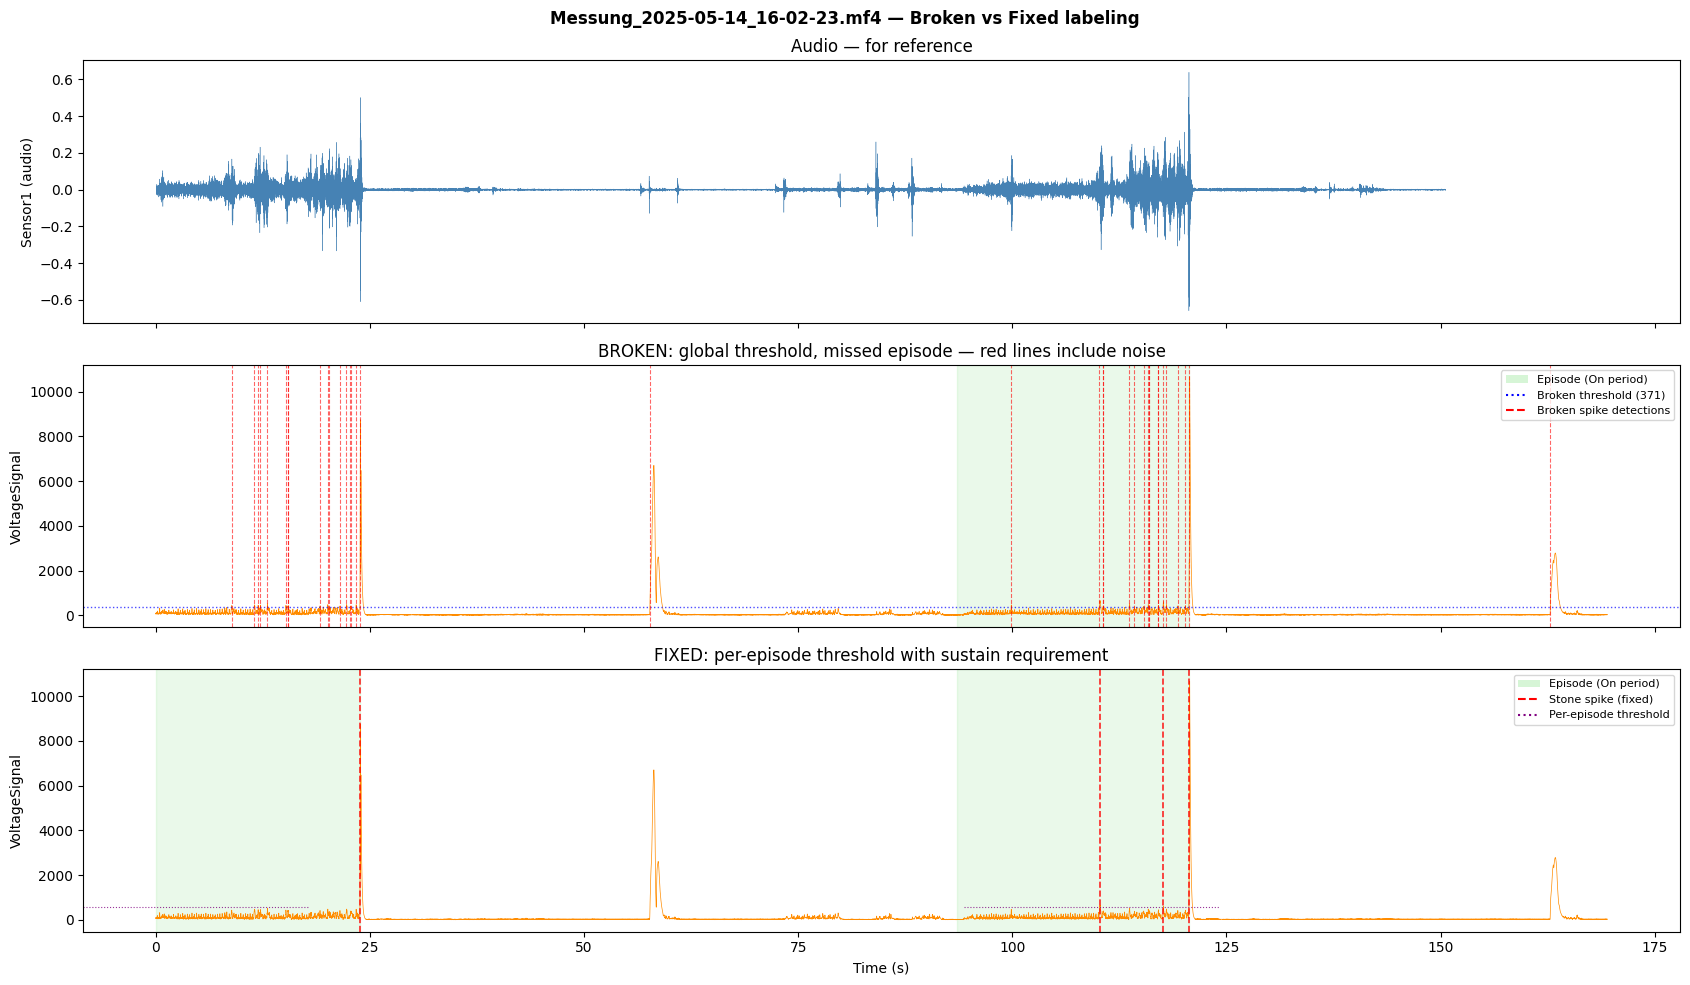

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(17, 10), sharex=True)
fig.suptitle(f"{RUN2.name} — Broken vs Fixed labeling", fontsize=12, fontweight="bold")

audio2 = mf2.get("Sensor1")
step = 100

axes[0].plot(audio2.timestamps[::step], audio2.samples[::step], lw=0.3, color="steelblue")
axes[0].set_ylabel("Sensor1 (audio)")
axes[0].set_title("Audio — for reference")

axes[1].plot(t, v, lw=0.5, color="darkorange")
axes[1].axhline(threshold_broken, color="blue", lw=1, linestyle=":", alpha=0.7)
axes[1].set_ylabel("VoltageSignal")
axes[1].set_title("BROKEN: global threshold, missed episode — red lines include noise")

axes[2].plot(t, v, lw=0.5, color="darkorange")
axes[2].set_ylabel("VoltageSignal")
axes[2].set_title("FIXED: per-episode threshold with sustain requirement")

for ep_s, ep_e in broken_episodes:
    axes[1].axvspan(ep_s, ep_e, alpha=0.1, color="limegreen")
for st in all_spike_times:
    axes[1].axvline(st, color="red", lw=0.8, linestyle="--", alpha=0.6)

for ep_s, ep_e in fixed_episodes:
    axes[2].axvspan(ep_s, ep_e, alpha=0.1, color="limegreen")
for ev in fixed_events:
    ep_s, ep_e = ev["episode"]
    axes[2].axhline(ev["threshold"], color="purple", lw=0.8, linestyle=":",
                    xmin=ep_s / t[-1], xmax=ep_e / t[-1], alpha=0.8)
    for st in ev["spike_times"]:
        axes[2].axvline(st, color="red", lw=1.2, linestyle="--", alpha=0.85)

axes[1].legend(handles=[
    mpatches.Patch(facecolor="limegreen", alpha=0.2, label="Episode (On period)"),
    plt.Line2D([0],[0], color="blue", linestyle=":", label=f"Broken threshold ({threshold_broken:.0f})"),
    plt.Line2D([0],[0], color="red", linestyle="--", label="Broken spike detections"),
], fontsize=8, loc="upper right")

axes[2].legend(handles=[
    mpatches.Patch(facecolor="limegreen", alpha=0.2, label="Episode (On period)"),
    plt.Line2D([0],[0], color="red", linestyle="--", label="Stone spike (fixed)"),
    plt.Line2D([0],[0], color="purple", linestyle=":", label="Per-episode threshold"),
], fontsize=8, loc="upper right")

axes[2].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

---
## Part 3 — Apply fixes to all 5 runs and review

In [10]:
print("=" * 65)
print("All runs — episode and stone event summary (FIXED)")
print("=" * 65)

for f in MF4_FILES:
    mf   = MDF(f)
    volt = mf.get("VoltageSignal")
    stat = mf.get("Status")
    
    episodes = get_episodes_fixed(stat)
    events   = get_stone_events_fixed(volt, episodes)
    
    print(f"\n{f.name}")
    for i, ev in enumerate(events):
        ep_s, ep_e = ev['episode']
        dur = ep_e - ep_s
        if ev['spike_times']:
            first_rel = ev['spike_times'][0] - ep_s
            n_spikes  = len(ev['spike_times'])
            print(f"  Ep {i+1}  [{ep_s:.1f}s→{ep_e:.1f}s  {dur:.1f}s]  "
                  f"STONE at +{first_rel:.3f}s  (threshold={ev['threshold']:.0f}, "
                  f"peak={ev['spike_peak']:.0f}, {n_spikes} onset(s))")
        else:
            print(f"  Ep {i+1}  [{ep_s:.1f}s→{ep_e:.1f}s  {dur:.1f}s]  "
                  f"no stone  (threshold={ev['threshold']:.0f}, "
                  f"peak={ev['spike_peak']:.0f})")

All runs — episode and stone event summary (FIXED)

Messung_2025-05-09_08-59-34.mf4
  Ep 1  [6.5s→29.5s  23.0s]  STONE at +0.436s  (threshold=190, peak=427, 94 onset(s))
  Ep 2  [53.1s→125.0s  71.9s]  STONE at +1.297s  (threshold=117, peak=499, 840 onset(s))
  Ep 3  [191.9s→249.5s  57.6s]  STONE at +1.174s  (threshold=121, peak=513, 709 onset(s))

Messung_2025-05-14_16-02-23.mf4
  Ep 1  [0.0s→23.9s  23.9s]  STONE at +23.839s  (threshold=571, peak=6092, 1 onset(s))
  Ep 2  [93.5s→120.6s  27.1s]  STONE at +16.673s  (threshold=558, peak=2289, 3 onset(s))

Messung_2025-05-20_16-30-26.mf4
  Ep 1  [1.7s→13.3s  11.6s]  STONE at +11.558s  (threshold=807, peak=2929, 1 onset(s))
  Ep 2  [81.9s→107.3s  25.4s]  no stone  (threshold=605, peak=583)
  Ep 3  [146.1s→158.9s  12.9s]  STONE at +1.861s  (threshold=194, peak=1438, 80 onset(s))
  Ep 4  [220.4s→239.3s  18.9s]  STONE at +3.775s  (threshold=632, peak=1707, 2 onset(s))
  Ep 5  [300.5s→323.4s  22.9s]  STONE at +22.914s  (threshold=650, peak=3802

---
## Part 4 — Zoom: verify each detected stone event looks real

For every episode where a spike was found, plot a tight window around it.
If the fix is correct, every red line should coincide with a visually obvious voltage spike —
not background ripple.

In [ ]:
def verify_stone_event_zoom(f, window_before=1.5, window_after=1.0):
    mf   = MDF(f)
    volt = mf.get("VoltageSignal")
    stat = mf.get("Status")
    audio = mf.get("Sensor1")

    episodes = get_episodes_fixed(stat)
    events   = get_stone_events_fixed(volt, episodes)

    stone_eps = [(ev, ep) for ev, ep in zip(events, episodes) if ev['spike_times']]
    if not stone_eps:
        print(f"{f.name}: no stone events detected after fix")
        return

    for ev, (ep_s, ep_e) in stone_eps:
        spike_t = ev['spike_times'][0]
        t_lo = spike_t - window_before
        t_hi = spike_t + window_after

        v = volt.samples
        tv = volt.timestamps
        ta = audio.timestamps
        sa = audio.samples

        vm = (tv >= t_lo) & (tv <= t_hi)
        am = (ta >= t_lo) & (ta <= t_hi)

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
        fig.suptitle(
            f"{f.name} — episode [{ep_s:.1f}s→{ep_e:.1f}s]\n"
            f"Spike at t={spike_t:.3f}s  threshold={ev['threshold']:.0f}  peak={ev['spike_peak']:.0f}",
            fontsize=9
        )

        ax1.plot(ta[am][::20] - spike_t, sa[am][::20], lw=0.4, color='steelblue')
        ax1.axvline(0, color='red', lw=1.5, linestyle='--', label='Spike onset (t=0)')
        ax1.axvspan(-window_before, 0, alpha=0.05, color='orange')
        ax1.set_ylabel("Audio")
        ax1.legend(fontsize=8)

        ax2.plot(tv[vm] - spike_t, v[vm], lw=0.8, color='darkorange')
        ax2.axhline(ev['threshold'], color='purple', lw=1, linestyle=':',
                    label=f"Per-episode threshold ({ev['threshold']:.0f})")
        ax2.axvline(0, color='red', lw=1.5, linestyle='--')
        ax2.set_ylabel("VoltageSignal")
        ax2.set_xlabel("Time relative to spike onset (s)")
        ax2.legend(fontsize=8)

        plt.tight_layout()
        plt.show()

for f in MF4_FILES:
    verify_stone_event_zoom(f)

---
## Summary

| Problem | Root cause | Fix |
|---------|-----------|-----|
| Missed episode at start | Code only looked for Off→On transitions | Seed episode detection with t=0 if Status starts On |
| False spike detections | Global threshold computed from full-run baseline | Per-episode threshold using Off period before each episode + minimum sustain requirement |

These two fixes together mean the red lines in the plots now represent events where:
1. The header was confirmed running (inside a valid episode)
2. The VoltageSignal showed a sustained, episode-relative spike — not background noise

These are the labels that should be used for model training in Task 2.